In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.optimize import curve_fit


def _to_str_list(mat_field):
    """
    Convert MATLAB cell/char arrays to a flat Python list of strings.
    Handles cases like: cell array of strings, char matrix, or object arrays.
    """
    x = np.squeeze(mat_field)
    if x.dtype.kind in ("U", "S"):  # already a (numpy) string array
        # char matrix (n x m) -> single string, else array of strings
        if x.ndim == 1:
            return [str(s) for s in x.tolist()]
        else:
            return ["".join(row).strip() for row in x.tolist()]
    # likely an object array (cell array)
    out = []
    for elem in np.ravel(x):
        s = elem
        # char arrays come as ndim>=2 with dtype 'U'/'S'
        if isinstance(elem, np.ndarray) and elem.dtype.kind in ("U", "S"):
            s = "".join(np.atleast_1d(elem).tolist()).strip()
        elif isinstance(elem, np.ndarray) and elem.dtype.kind in ("i", "f"):
            s = str(elem.item()) if elem.size == 1 else "".join(map(str, elem.tolist()))
        else:
            s = str(elem)
        out.append(s)
    return out

In [2]:
directory = "/mnt/hcleroy/PostDoc2/octopus_smelling/experimental_data/matlab_files/v2"
mat_path = directory+"/20260120_HiPlexResults.mat"
# --- Load .mat ---
md = loadmat(mat_path, squeeze_me=True, struct_as_record=False)
if "binaryTable_Stack" not in md or "CRnames" not in md:
    raise KeyError("Expected fields 'binaryTable_Stack' and 'CRnames' in the .mat file.")

A = np.array(md["binaryTable_Stack"]).astype(bool).astype(int)  # shape: (n_receptors, n_cells)
CRnames = _to_str_list(md["CRnames"])
nR, nC = A.shape


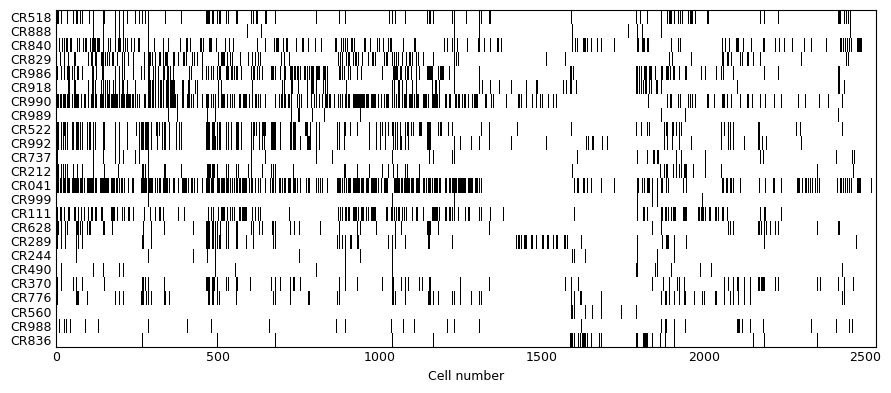

In [3]:

# ===============================
# RASTER PLOT WITH ALL CELLS
# ===============================
plt.figure(figsize=(9, 4))  # ~900x400 px
plt.imshow(A, aspect="auto", cmap="gray_r", interpolation="nearest")
plt.xlabel("Cell number", fontsize=9)
plt.yticks(np.arange(nR), CRnames)
ax = plt.gca()
ax.tick_params(length=0, labelsize=9)
plt.tight_layout()

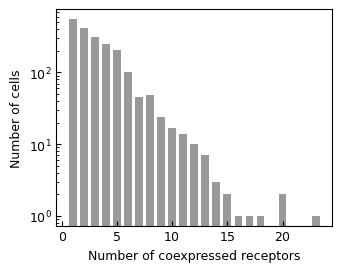

In [4]:
# =========================================
# HISTOGRAM: NUMBER OF COEXPRESSED SUBUNITS
# =========================================
coexp = A.sum(axis=0)  # per cell
coexp_nz = coexp[coexp != 0]
# integer bins: use bincount for exact integer histogram
if coexp_nz.size > 0:
    max_k = int(coexp_nz.max())
    counts = np.bincount(coexp_nz, minlength=max_k + 1)[1:]  # skip zero bin
    centers = np.arange(1, max_k + 1)
else:
    counts = np.array([])
    centers = np.array([])

plt.figure()
plt.bar(centers, counts, width=0.7, color=[0.6, 0.6, 0.6])
plt.ylabel("Number of cells", fontsize=9)
plt.xlabel("Number of coexpressed receptors", fontsize=9)
plt.gca().tick_params(labelsize=9)
plt.tight_layout()
plt.yscale('log')

In [5]:
Proba_L = counts/np.sum(counts)
print(np.sum(Proba_L))

def exp_distrib(l,beta):
    return beta*np.exp(-beta * l )

popt, pcov = curve_fit(exp_distrib, centers, Proba_L, p0=1, bounds=(0.1, 1))

print(popt)

1.0000000000000002
[0.371177]


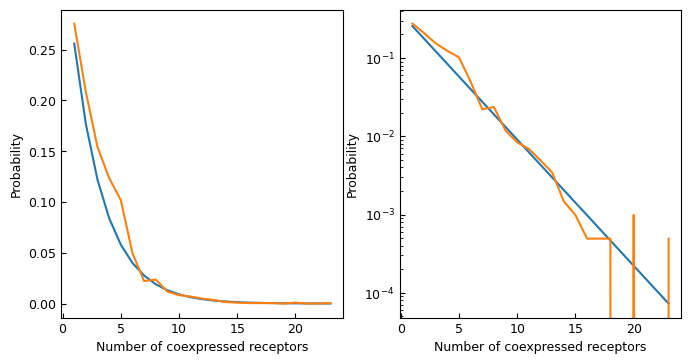

In [6]:
fig,ax = plt.subplots(ncols=2,figsize=(8,4))
ax[0].plot(centers,exp_distrib(centers,popt[0]))
ax[0].plot(centers,Proba_L)

ax[1].plot(centers,exp_distrib(centers,popt[0]))
ax[1].plot(centers,Proba_L)
plt.yscale('log')

for i in range(2):
    ax[i].set_xlabel('Number of coexpressed receptors')
    ax[i].set_ylabel('Probability')

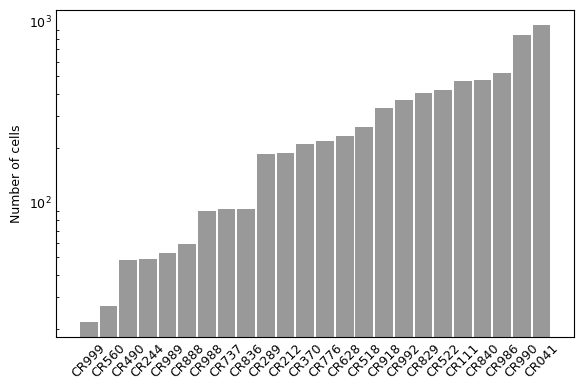

In [7]:
# ================================================
# RELATIVE ABUNDANCE OF EACH RECEPTOR IN POPULATION
# ================================================
CR_counts = A.sum(axis=1)  # per receptor
plt.figure(figsize=(6, 4.))  # ~500x250 px
plt.bar(np.arange(1, nR + 1), CR_counts[np.argsort(CR_counts)], width=0.9, color=[0.6, 0.6, 0.6])
plt.ylabel("Number of cells", fontsize=9)
plt.xticks(np.arange(1, nR + 1), np.array(CRnames)[np.argsort(CR_counts)], rotation=45)
ax = plt.gca()
ax.tick_params(length=0, labelsize=9)
plt.tight_layout()
plt.yscale('log')

In [8]:
proba_unit = CR_counts/np.sum(CR_counts)
print(proba_unit)

[0.03969212 0.00890432 0.07168729 0.06082101 0.07847872 0.05040749
 0.12677332 0.00799879 0.06338666 0.05584063 0.0138847  0.028524
 0.14473287 0.00332025 0.07123453 0.0351645  0.02807123 0.00739511
 0.00724419 0.03169333 0.03320254 0.00407486 0.01358286 0.0138847 ]


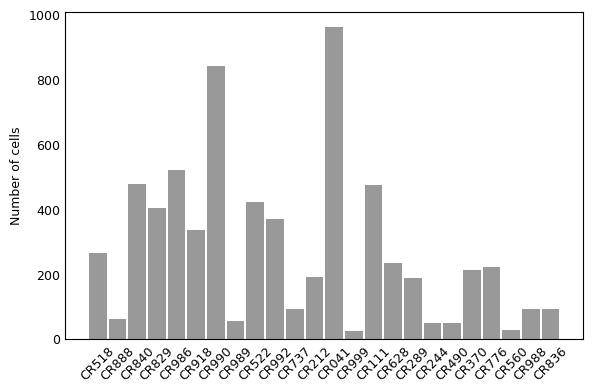

In [9]:
# ================================================
# RELATIVE ABUNDANCE OF EACH RECEPTOR IN POPULATION
# ================================================
CR_counts = A.sum(axis=1)  # per receptor
plt.figure(figsize=(6, 4))  # ~500x250 px
plt.bar(np.arange(1, nR + 1), CR_counts, width=0.9, color=[0.6, 0.6, 0.6])
plt.ylabel("Number of cells", fontsize=9)
plt.xticks(np.arange(1, nR + 1), CRnames, rotation=45)
ax = plt.gca()
ax.tick_params(length=0, labelsize=9)
plt.tight_layout()

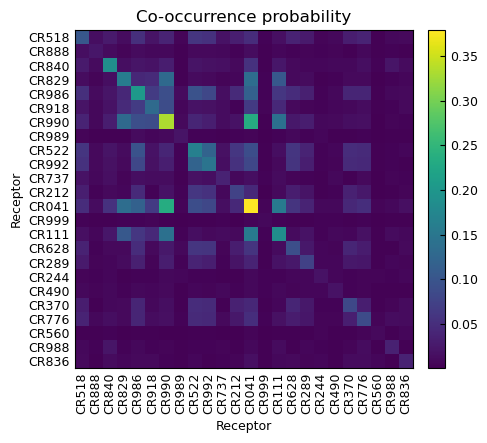

In [10]:
# ==================
# PAIRS LIKELIHOODS
# ==================
# Co-occurrence counts and probability (receptor x receptor)
pairComparison = A @ A.T  # (nR x nR)
pairProb = pairComparison / float(nC)

plt.figure(figsize=(5, 4.5))
im = plt.imshow(pairProb, aspect="equal", cmap="viridis", interpolation="nearest")
plt.title("Co-occurrence probability", fontsize=12)
plt.xlabel("Receptor", fontsize=9)
plt.ylabel("Receptor", fontsize=9)
plt.xticks(np.arange(nR), CRnames, rotation=90)
plt.yticks(np.arange(nR), CRnames)
plt.gca().tick_params(length=0, labelsize=9)
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)  # Adjust fraction and pad as needed
plt.tight_layout()

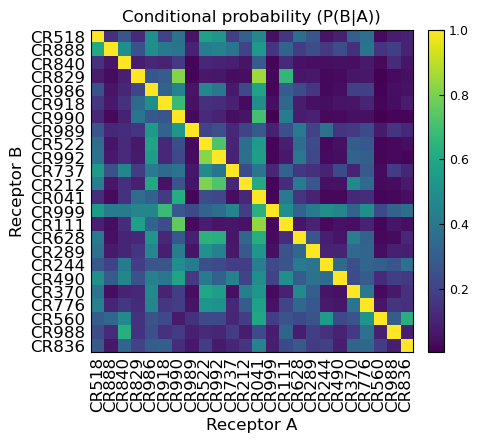

In [11]:
# Conditional probability: MATLAB code computes P(B|A) = pairComparison[i,j]/numCells_perCR[i]
numCells_perCR = np.diag(pairComparison).astype(float)  # size (nR,)
with np.errstate(invalid="ignore", divide="ignore"):
    condProb = pairComparison / numCells_perCR[:, None]  # broadcast over columns
condProb = np.where(np.isfinite(condProb), condProb, np.nan)

plt.figure(figsize=(5, 4.5))
im = plt.imshow(condProb, aspect="equal", cmap="viridis", interpolation="nearest")
plt.title("Conditional probability (P(B|A))", fontsize=12)
plt.xlabel("Receptor A", fontsize=12)
plt.ylabel("Receptor B", fontsize=12)
plt.xticks(np.arange(nR), CRnames, rotation=90)
plt.yticks(np.arange(nR), CRnames)
plt.gca().tick_params(length=0, labelsize=12)
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)  # Adjust fraction and pad as needed
plt.tight_layout()

In [12]:

# ===========================
# NUMBER OF UNIQUE COMBINATIONS
# ===========================
M_cells = A.T  # shape ~ (n_cells x n_receptors)
# 'stable' unique rows: use return_index to preserve first occurrence order
uniq_rows, idx_first, inv_idx = np.unique(M_cells, axis=0, return_index=True, return_inverse=True)
# sort unique rows by first occurrence (stable)
order_stable = np.argsort(idx_first)
uniquePatterns = uniq_rows[order_stable]
# counts per pattern (based on inverse index)
counts = np.bincount(inv_idx)
# reorder counts to match uniquePatterns order
counts = counts[np.argsort(idx_first)]

uniqueReceptors = uniquePatterns.shape[0]
print(f"Number of unique expression patterns: {uniqueReceptors}")

Number of unique expression patterns: 604


In [13]:
# Most common patterns
order_counts = np.argsort(counts)[::-1]
topPatt = min(100, uniqueReceptors)
print("Top patterns:")
print(counts[order_counts][:topPatt])

for nPatt in range(topPatt):
    patternIdx = order_counts[nPatt]
    genesOn_mask = uniquePatterns[patternIdx].astype(bool)
    genesOn = [CRnames[i] for i, on in enumerate(genesOn_mask) if on]
    print(f"\nPattern {nPatt+1} (appears {counts[patternIdx]} times):")
    print(genesOn)

Top patterns:
[502 222 106 101  60  56  54  40  39  32  31  31  28  24  23  22  21  21
  20  19  19  18  16  15  15  15  15  13  13  13  13  11  11   9   9   9
   9   9   9   9   8   8   8   8   8   8   7   7   6   6   6   5   5   5
   5   5   5   5   5   5   4   4   4   4   4   4   4   4   4   4   4   4
   4   4   3   3   3   3   3   3   3   3   3   3   3   3   3   3   3   3
   3   3   3   3   3   3   3   3   3   3]

Pattern 1 (appears 502 times):
[]

Pattern 2 (appears 222 times):
['CR840']

Pattern 3 (appears 106 times):
['CR829', 'CR990', 'CR041', 'CR111']

Pattern 4 (appears 101 times):
['CR990', 'CR041']

Pattern 5 (appears 60 times):
['CR990']

Pattern 6 (appears 56 times):
['CR041']

Pattern 7 (appears 54 times):
['CR990', 'CR041', 'CR111']

Pattern 8 (appears 40 times):
['CR840', 'CR041']

Pattern 9 (appears 39 times):
['CR829', 'CR918', 'CR990', 'CR041', 'CR111']

Pattern 10 (appears 32 times):
['CR829', 'CR986', 'CR990', 'CR041', 'CR111']

Pattern 11 (appears 31 times):
['CR

Text(0.5, 1.0, 'Overlapping batches')

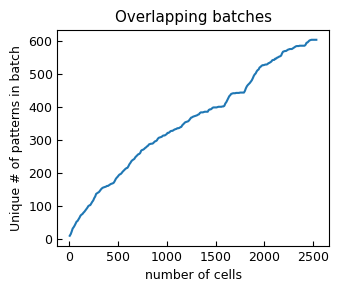

In [14]:
# ===========================
# BATCH ANALYSIS - MOVING WINDOWS (cumulative windows like MATLAB)
# ===========================
nCells = M_cells.shape[0]
batchEdge = np.arange(10, nCells + 1, 10)  # 10:10:nCells
nBatches = len(batchEdge)
uniquePerBatch = np.zeros(nBatches, dtype=int)
startIdx = 0  # Python 0-based

for b, edge in enumerate(batchEdge):
    stopIdx = min(startIdx + edge, nCells)  # cumulative from start
    if startIdx >= nCells:
        break
    sub = M_cells[startIdx:stopIdx, :]
    # unique rows count
    uniquePerBatch[b] = np.unique(sub, axis=0).shape[0]

plt.figure()
plt.plot(batchEdge, uniquePerBatch)
plt.xlabel("number of cells")
plt.ylabel("Unique # of patterns in batch")
plt.title("Overlapping batches")
    
# thinner x-tick labels
#numLabels = min(10, nBatches)
#idxLabels = np.unique(np.round(np.linspace(1, nBatches, numLabels)).astype(int))
#plt.xticks(idxLabels, [str(i) for i in idxLabels])
#plt.tight_layout()


/tmp/ipykernel_15091/2435327361.py:55: RuntimeWarning: invalid value encountered in sqrt
  std_devs = np.sqrt(variances)


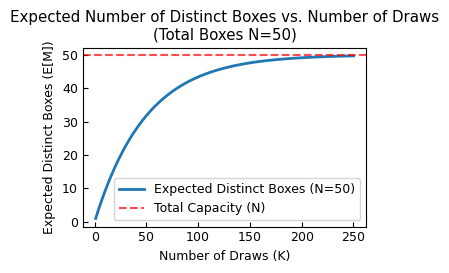

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb, stirling2

def probability_exact_m(N, K, M):
    """
    Calculates the probability of finding exactly M distinct boxes
    after K draws from N total boxes.
    """
    # Constraints
    if M > K or M > N or M < 1:
        return 0.0
    
    # Formula: (Binom(N, M) * M! * Stirling2(K, M)) / N^K
    # We use python's arbitrary precision integers for the numerator/denominator
    # before dividing to avoid early float overflow.
    
    # 1. Choose M boxes out of N
    ways_to_choose_boxes = comb(N, M, exact=True)
    
    # 2. Surject K balls onto M boxes (Stirling2 * M!)
    ways_to_fill_boxes = stirling2(K, M, exact=True) * np.math.factorial(M)
    
    numerator = ways_to_choose_boxes * ways_to_fill_boxes
    denominator = N**K
    
    return numerator / denominator

def expected_value_closed_form(N, K):
    """
    Calculates E[M] using the linearity of expectation shortcut.
    This is much faster than summing M * P(M).
    """
    return N * (1 - ((N - 1) / N)**K)

# --- Plotting Configuration ---
N = 50  # Total number of boxes
max_K = 250 # Max draws to simulate

K_values = np.arange(1, max_K + 1)

# Calculate E[M] for all K
expected_values = [expected_value_closed_form(N, k) for k in K_values]

# Calculate the Standard Deviation for the shaded region (Uncertainty)
# Var(M) = N(N-1)((N-2)/N)^K + N((N-1)/N)^K - (E[M])^2
variances = []
for k in K_values:
    term1 = N * (N - 1) * ((N - 2) / N)**k
    term2 = N * ((N - 1) / N)**k
    exp_sq = expected_value_closed_form(N, k)**2
    var = term1 + term2 - exp_sq
    variances.append(var)

std_devs = np.sqrt(variances)
upper_bound = np.array(expected_values) + std_devs
lower_bound = np.array(expected_values) - std_devs

# --- Generate Plot ---

# Plot Mean
plt.plot(K_values, expected_values, label=f'Expected Distinct Boxes (N={N})', color='#1f77b4', linewidth=2)

# Plot Confidence Interval (Mean +/- 1 Std Dev)
#plt.fill_between(K_values, lower_bound, upper_bound, color='#1f77b4', alpha=0.2, label='Standard Deviation (±1σ)')

# Reference Line for Capacity (N)
plt.axhline(y=N, color='r', linestyle='--', alpha=0.7, label='Total Capacity (N)')

plt.title(f'Expected Number of Distinct Boxes vs. Number of Draws\n(Total Boxes N={N})')
plt.xlabel('Number of Draws (K)')
plt.ylabel('Expected Distinct Boxes (E[M])')
plt.legend(loc='lower right')
plt.tight_layout()

#plt.savefig('expected_occupancy_plot.png')

Estimated total number of independent combinations (N): 604.0000


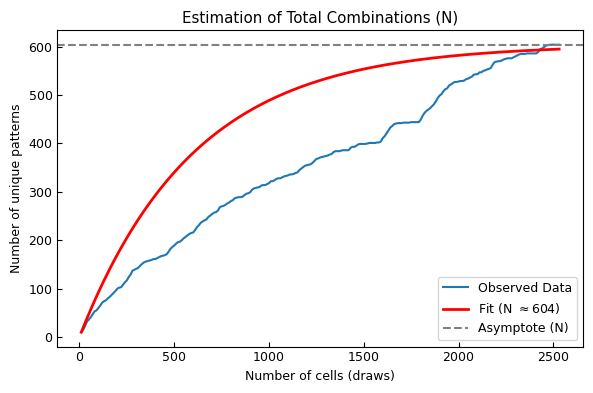

In [22]:
from scipy.optimize import curve_fit

def model_func(k, n):
    """
    Expected number of unique items M after k draws from N total items with replacement.
    E[M] = N * (1 - ((N-1)/N)^k)
    """
    return n * (1 - ((n - 1) / n) ** k)

# Use the data from the previous cell: batchEdge and uniquePerBatch
# Initial guess for N. It must be >= max observed unique patterns.
max_unique = uniquePerBatch.max()
p0 = [max_unique * 1.2]

try:
    # Curve fit
    # Bounds: N >= max_unique
    popt, pcov = curve_fit(model_func, batchEdge, uniquePerBatch, p0=p0, bounds=(max_unique, np.inf))
    
    N_est = popt[0]
    print(f"Estimated total number of independent combinations (N): {N_est:.4f}")
    
    # Plotting the result
    plt.figure(figsize=(6, 4))
    plt.plot(batchEdge, uniquePerBatch, label='Observed Data')
    
    # Plot the fitted curve
    # Extend the range slightly to see saturation if applicable
    x_fit = np.linspace(0, batchEdge.max() * 1.2, 100)
    # Avoid x=0 for the formula if handled strictly, but 0 draws = 0 items is fine.
    # For plotting, let's start from 1
    x_fit = np.linspace(1, batchEdge.max() * 1.5, 200)
    y_fit = model_func(batchEdge, N_est)
    
    plt.plot(batchEdge, y_fit, 'r-', linewidth=2, label=r'Fit (N $\approx$'+f'{int(round(N_est))})')
    
    plt.axhline(N_est, color='gray', linestyle='--', label='Asymptote (N)')
    
    plt.xlabel("Number of cells (draws)")
    plt.ylabel("Number of unique patterns")
    plt.title("Estimation of Total Combinations (N)")
    plt.legend()
    #plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"Error during fitting: {e}")
